# Exploratory Data Analysis — Movie Recommendation System

## Purpose
Each analysis section answers a specific question that informs a modeling decision.
This is not random plotting — every chart has a purpose.

## Dataset
MovieLens 25M — 25 million ratings, ~62K movies, ~162K users.

## Pipeline so far
1. Raw data loaded from `data/raw/ml-25m/`
2. Temporal split (before any filtering — no leakage)
3. Train-only user/movie filtering
4. Temporal tag cutoff
5. ID remapping (originals kept)
6. Saved to `data/processed/` as parquet

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))
from src.utils.config import cfg

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

print("Setup complete")

Setup complete


## Load Processed Data
Loading from parquet files — fast because preprocessing is already done.

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
movies = pd.read_parquet("../data/processed/movies_clean.parquet")

all_ratings = pd.concat([train, val, test], ignore_index=True)

n_users = all_ratings["userId"].nunique()
n_movies = all_ratings["movieId"].nunique()
sparsity = 1 - len(all_ratings) / (n_users * n_movies)

print(f"Total ratings:  {len(all_ratings):>12,}")
print(f"Train ratings:  {len(train):>12,}")
print(f"Val ratings:    {len(val):>12,}")
print(f"Test ratings:   {len(test):>12,}")
print(f"Users:          {n_users:>12,}")
print(f"Movies:         {n_movies:>12,}")
print(f"Sparsity:       {sparsity:>11.4%}")

Total ratings:    24,780,937
Train ratings:    24,472,597
Val ratings:         154,198
Test ratings:        154,142
Users:               154,499
Movies:               32,567
Sparsity:          99.5075%


## 1. Rating Distribution
**Question:** Is our relevance threshold (≥ 4.0) reasonable?

If too few ratings are above 4.0, we won't have enough positive signal.
If too many, the threshold is too loose.

Mean rating:    3.53
Median rating:  3.5
% >= 4.0:      49.8%


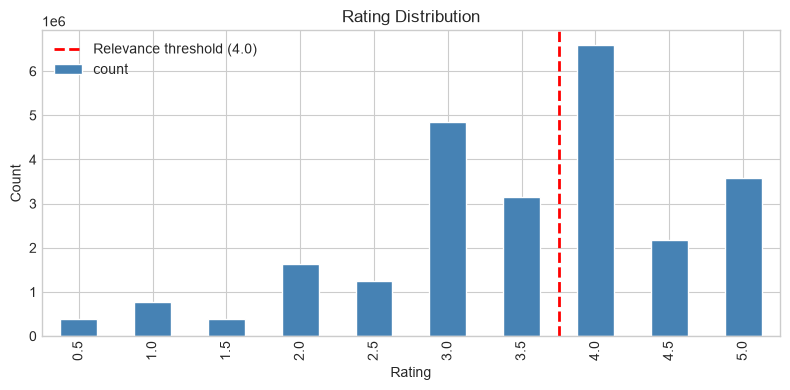

In [3]:
rating_counts = all_ratings["rating"].value_counts().sort_index()
pct_relevant = (all_ratings["rating"] >= cfg.evaluation.relevance_threshold).mean()

print(f"Mean rating:    {all_ratings['rating'].mean():.2f}")
print(f"Median rating:  {all_ratings['rating'].median():.1f}")
print(f"% >= {cfg.evaluation.relevance_threshold}:      {pct_relevant:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
rating_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
threshold_idx = list(rating_counts.index).index(cfg.evaluation.relevance_threshold)
ax.axvline(x=threshold_idx - 0.5, color="red", linestyle="--", linewidth=2,
           label=f"Relevance threshold ({cfg.evaluation.relevance_threshold})")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.set_title("Rating Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 2. User Activity Distribution
**Question:** How active are users? What does the typical user look like?

This informs our cold-start threshold and how much data each user 
contributes to training.

Ratings per user (train set):
  P10: 25
  P25: 37
  P50: 74
  P75: 168
  P90: 364
  P95: 568
  P99: 1245


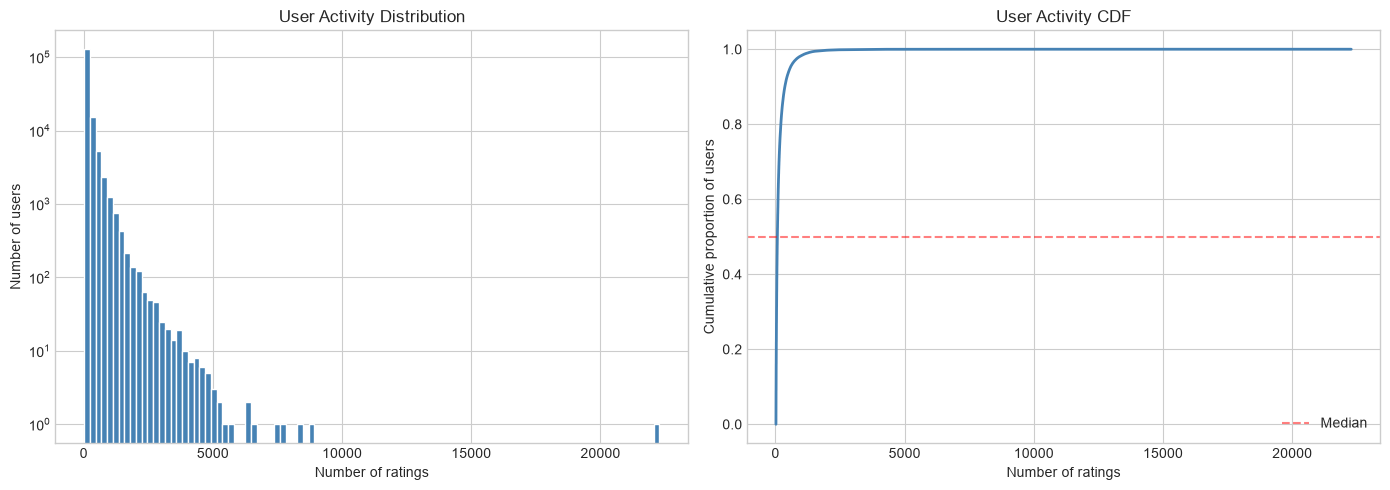

In [4]:
user_counts = train.groupby("userId").size()

percentiles = [10, 25, 50, 75, 90, 95, 99]
print("Ratings per user (train set):")
for p in percentiles:
    print(f"  P{p:>2}: {user_counts.quantile(p / 100):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].set_title("User Activity Distribution")
axes[0].set_yscale("log")

sorted_counts = np.sort(user_counts.values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color="steelblue", linewidth=2)
axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Median")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Cumulative proportion of users")
axes[1].set_title("User Activity CDF")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Movie Popularity — Long Tail
**Question:** How dominant are popular movies?

This tells us how hard it will be to beat a simple popularity baseline.
If most ratings go to a few movies, popularity alone does well.

Top 1% movies (325 movies) account for 34.8% of all ratings
Bottom 50% movies account for 0.7% of all ratings


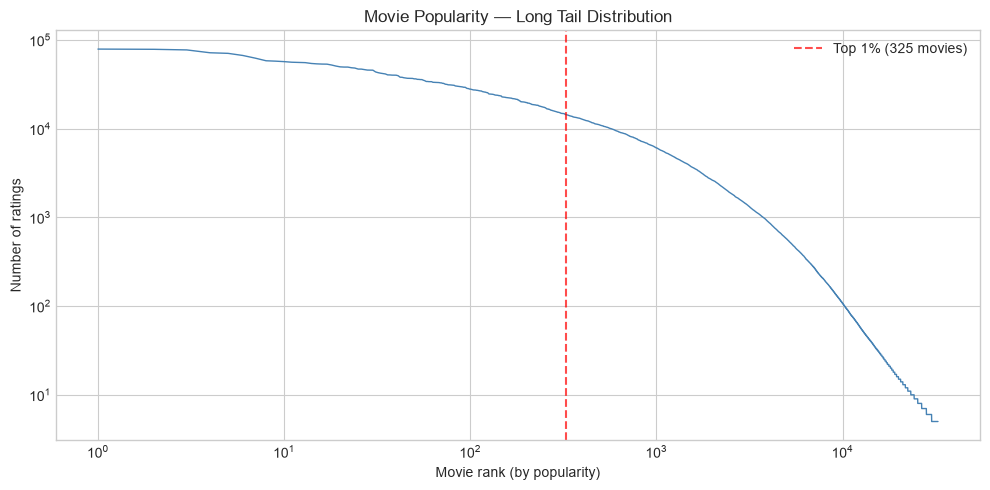

In [5]:
movie_counts = train.groupby("movieId").size().sort_values(ascending=False)
top_1pct = int(len(movie_counts) * 0.01)
top_1pct_ratings = movie_counts.head(top_1pct).sum()
bottom_50pct_ratings = movie_counts.tail(len(movie_counts) // 2).sum()

print(f"Top 1% movies ({top_1pct} movies) account for {top_1pct_ratings / len(train):.1%} of all ratings")
print(f"Bottom 50% movies account for {bottom_50pct_ratings / len(train):.1%} of all ratings")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(movie_counts) + 1), movie_counts.values,
        color="steelblue", linewidth=1)
ax.axvline(x=top_1pct, color="red", linestyle="--", alpha=0.7,
           label=f"Top 1% ({top_1pct} movies)")
ax.set_xlabel("Movie rank (by popularity)")
ax.set_ylabel("Number of ratings")
ax.set_title("Movie Popularity — Long Tail Distribution")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Temporal Patterns
**Question:** Are rating patterns stable over time?

If there's significant drift in rating behavior, our temporal split 
might not generalize well. We check both volume and average rating 
over time.

Date range: 1995-01-09 to 2019-11-21
Months with data: 287
Avg rating range: 3.36 - 4.17


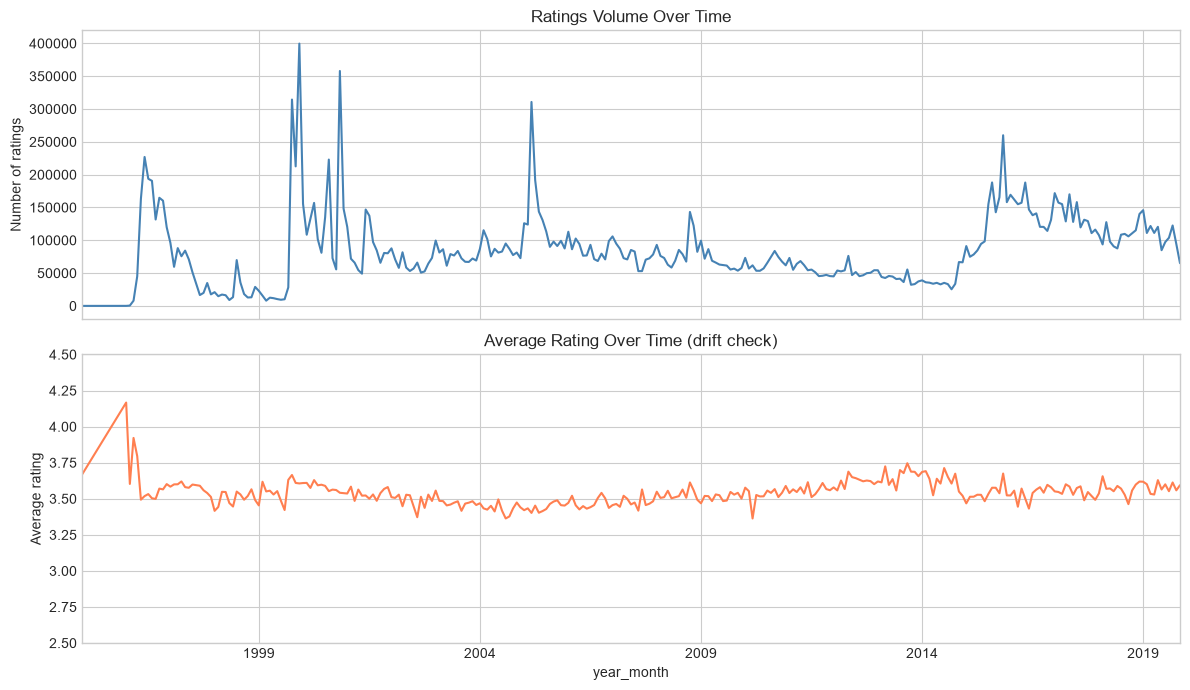

In [6]:
all_ratings["datetime"] = pd.to_datetime(all_ratings["timestamp"], unit="s")
all_ratings["year_month"] = all_ratings["datetime"].dt.to_period("M")

monthly_counts = all_ratings.groupby("year_month").size()
monthly_avg = all_ratings.groupby("year_month")["rating"].mean()

print(f"Date range: {all_ratings['datetime'].min().date()} to {all_ratings['datetime'].max().date()}")
print(f"Months with data: {len(monthly_counts)}")
print(f"Avg rating range: {monthly_avg.min():.2f} - {monthly_avg.max():.2f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

monthly_counts.plot(ax=axes[0], color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Number of ratings")
axes[0].set_title("Ratings Volume Over Time")

monthly_avg.plot(ax=axes[1], color="coral", linewidth=1.5)
axes[1].set_ylabel("Average rating")
axes[1].set_title("Average Rating Over Time (drift check)")
axes[1].set_ylim(2.5, 4.5)

plt.tight_layout()
plt.show()

## 5. Genre Analysis
**Question:** Which genres dominate? How do they co-occur?

Informs content-based feature design — if genres co-occur heavily
(e.g. Action+Adventure always together), TF-IDF will capture this 
redundancy. Also shows which genres have enough data.

Top 10 genres:
  Drama: 14,763 movies
  Comedy: 9,941 movies
  Thriller: 5,266 movies
  Romance: 4,515 movies
  Action: 4,291 movies
  Horror: 3,565 movies
  Crime: 3,216 movies
  Adventure: 2,637 movies
  Documentary: 2,632 movies
  Sci-Fi: 2,316 movies


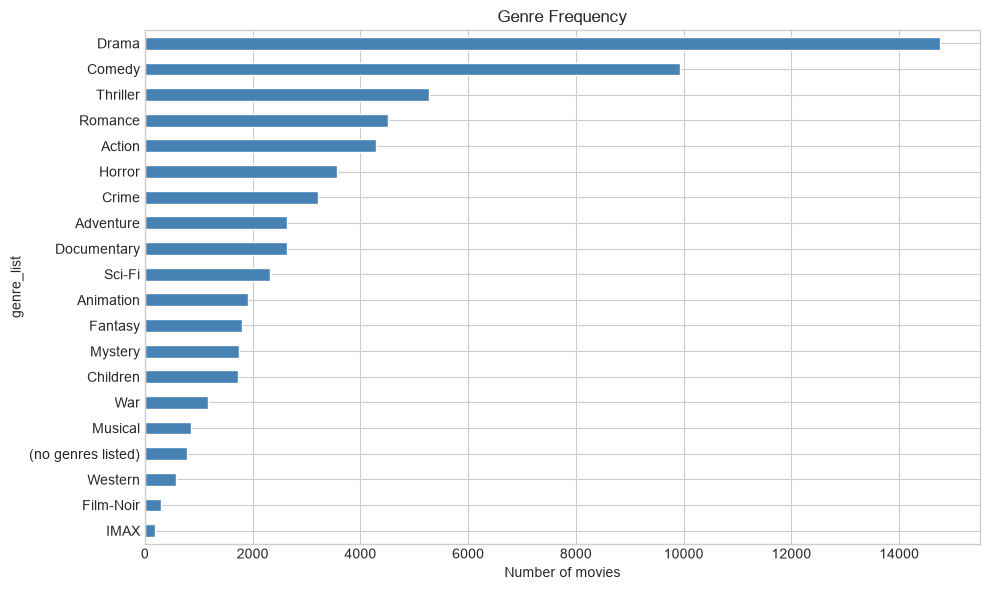

In [7]:
movies_genres = movies.copy()
movies_genres["genre_list"] = movies_genres["genres"].str.split("|")
genre_exploded = movies_genres.explode("genre_list")

genre_freq = genre_exploded["genre_list"].value_counts()
print("Top 10 genres:")
for g, c in genre_freq.head(10).items():
    print(f"  {g}: {c:,} movies")

fig, ax = plt.subplots(figsize=(10, 6))
genre_freq.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of movies")
ax.set_title("Genre Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

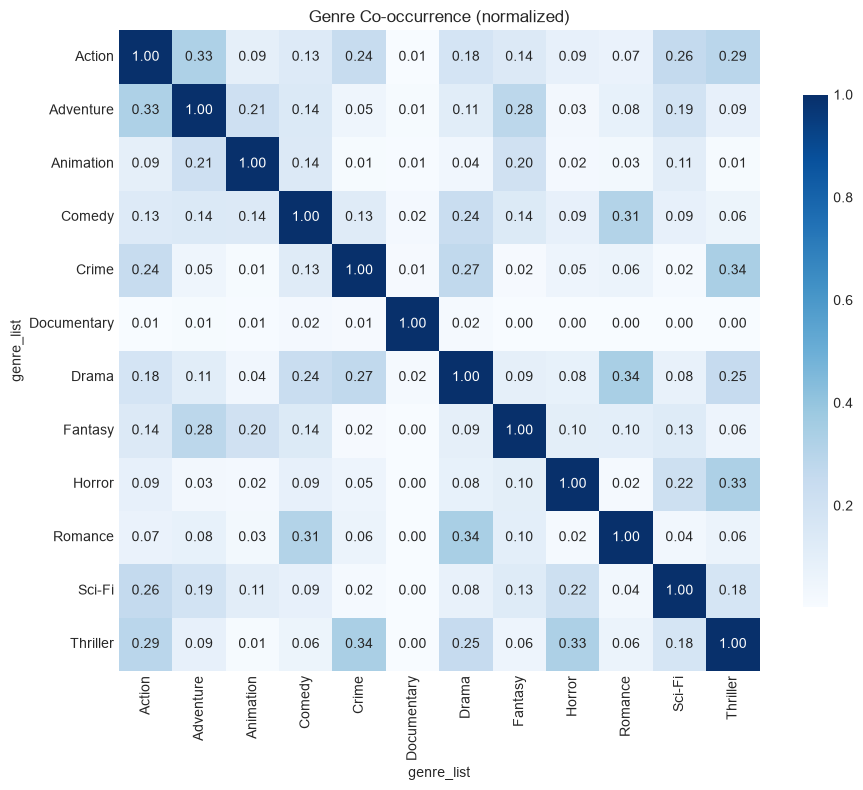

In [9]:
top_genres = genre_freq.head(12).index.tolist()
movie_genre = genre_exploded[genre_exploded["genre_list"].isin(top_genres)]

# Create clean binary movie-genre matrix
binary = (
    movie_genre.assign(val=1)
    .pivot_table(index="movieId", columns="genre_list", values="val", fill_value=0)
)

# Co-occurrence: count movies that share both genres
co_matrix = binary.T.dot(binary)

# Normalize (cosine-like: divide by sqrt of product of individual counts)
diag = np.diag(co_matrix.values).astype(float)
norm = np.sqrt(np.outer(diag, diag))
norm[norm == 0] = 1
co_norm = co_matrix.values / norm
np.fill_diagonal(co_norm, 1.0)

co_df = pd.DataFrame(co_norm, index=co_matrix.index, columns=co_matrix.columns)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_df, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Genre Co-occurrence (normalized)")
plt.tight_layout()
plt.show()

## 6. Tags Coverage
**Question:** Do tags provide enough signal for content-based?

Tags are free-text labels users apply to movies (e.g. "mind-bending", 
"great soundtrack"). If coverage is low, we'll need TMDb enrichment.

In [10]:
has_tags = movies["tags_text"].notna() & (movies["tags_text"] != "")
n_with_tags = has_tags.sum()

print(f"Movies with tags: {n_with_tags:,} / {len(movies):,} ({n_with_tags / len(movies):.1%})")

tag_word_counts = movies.loc[has_tags, "tags_text"].str.split().str.len()
print(f"Tag words per movie (median): {tag_word_counts.median():.0f}")
print(f"Tag words per movie (mean):   {tag_word_counts.mean():.1f}")
print(f"Tag words per movie (P90):    {tag_word_counts.quantile(0.9):.0f}")

# Show example
example = movies.loc[has_tags].sort_values("movieId").iloc[0]
print(f"\nExample — {example['title']}:")
print(f"  Genres: {example['genres']}")
print(f"  Tags: {example['tags_text'][:200]}...")

Movies with tags: 28,690 / 32,567 (88.1%)
Tag words per movie (median): 12
Tag words per movie (mean):   23.1
Tag words per movie (P90):    54

Example — Toy Story (1995):
  Genres: Adventure|Animation|Children|Comedy|Fantasy
  Tags: 2009 reissue in stereoscopic 3-d 3d 55 movies every kid should see--entertainment weekly action action figure action figures adventure american animation animated animation animmation avi bd-video bes...


## 7. Cold-Start Analysis
**Question:** How many users/movies have too little training data?

This directly justifies the hybrid model. If many movies have very few 
ratings in training, collaborative filtering alone won't work for them 
and we need content-based as fallback.

In [11]:
train_user_counts = train.groupby("userId").size()
train_movie_counts = train.groupby("movieId").size()

print("Cold-start users (few train ratings):")
for t in [5, 10, 20, 30]:
    n = (train_user_counts < t).sum()
    print(f"  < {t:>2} ratings: {n:>6,} users ({n / len(train_user_counts):.1%})")

print()
print("Cold-start movies (few train ratings):")
for t in [5, 10, 20, 50]:
    n = (train_movie_counts < t).sum()
    print(f"  < {t:>2} ratings: {n:>6,} movies ({n / len(train_movie_counts):.1%})")

Cold-start users (few train ratings):
  <  5 ratings:      0 users (0.0%)
  < 10 ratings:      0 users (0.0%)
  < 20 ratings:      0 users (0.0%)
  < 30 ratings: 24,809 users (16.1%)

Cold-start movies (few train ratings):
  <  5 ratings:      0 movies (0.0%)
  < 10 ratings:  8,340 movies (25.6%)
  < 20 ratings: 14,203 movies (43.6%)
  < 50 ratings: 19,463 movies (59.8%)


## 8. Split Validation
**Question:** Is there temporal leakage in our split?

Final check that no future information leaked into training data.

In [12]:
train_max_ts = train.groupby("userId")["timestamp"].max()
test_min_ts = test.groupby("userId")["timestamp"].min()
common = train_max_ts.index.intersection(test_min_ts.index)
n_leaks = (train_max_ts[common] >= test_min_ts[common]).sum()

print(f"Users with potential temporal overlap: {n_leaks:,}")
print(f"Train period: {pd.to_datetime(train['timestamp'].min(), unit='s').date()} — "
      f"{pd.to_datetime(train['timestamp'].max(), unit='s').date()}")
print(f"Test period:  {pd.to_datetime(test['timestamp'].min(), unit='s').date()} — "
      f"{pd.to_datetime(test['timestamp'].max(), unit='s').date()}")

Users with potential temporal overlap: 13,111
Train period: 1995-01-09 — 2019-11-21
Test period:  1996-02-23 — 2019-11-21


In [13]:
# Verify: these are tied timestamps, not real leakage
overlap_users = common[train_max_ts[common] >= test_min_ts[common]]
sample_user = overlap_users[0]
user_ratings = pd.concat([train, test])[
    pd.concat([train, test])["userId"] == sample_user
].sort_values("timestamp")

print(f"Example user {sample_user} — last 5 ratings:")
print(user_ratings.tail()[["userId", "movieId", "rating", "timestamp"]])
print(f"\nSame timestamp for last entries = tied timestamps, not leakage")

Example user 8 — last 5 ratings:
      userId  movieId  rating  timestamp
1438       8     1783     3.0  890511503
1439       8      325     3.0  890511598
1440       8      440     4.0  890511598
1441       8      209     4.0  891279691
7          8      725     3.0  891279691

Same timestamp for last entries = tied timestamps, not leakage


## EDA Summary — Key Findings & Modeling Decisions

| Finding | Value | Decision |
|---------|-------|----------|
| Sparsity | 99.5% | Matrix factorization needed — raw matrix too sparse |
| Ratings ≥ 4.0 | 49.8% | Threshold 4.0 validated — enough positive signal |
| Long tail | Top 1% movies = 34.8% of ratings | Popularity baseline will be strong — must beat it |
| Tag coverage | 88.1% movies have tags | Good signal for content-based |
| Cold-start movies | 25.6% have < 10 ratings | Hybrid model justified — CF alone fails here |
| Temporal stability | Avg rating stable 3.4-3.7 | Temporal split is valid |
| Tied timestamps | 13K users | Not real leakage — documented |